# Assignment: Fine-tuning CLIP for Image–Text Retrieval (Part 2)

**Name (Student ID):**  
1. LI JIARU (A0332008U)

2. JIN YINAN (A0327317E)

3. SHI YANCHUN (A0328710J)

4. XIAO XIAO (A0332142W)

**Total Marks: 25**  
**Rubric:** Each step shows its mark weight. Auto-check cells provide partial verification. Keep the notebook runnable on a personal computer.


## Objective

In Part 1, CLIP was used as a fixed feature extractor. In this part, you will **fine-tune** CLIP for image–text retrieval on a small paired dataset (**Flickr8k**) using a **parameter-efficient** approach. We will **freeze** the image and text encoders and train only the **projection layers**.

**Tasks**
- Load and split Flickr8k, wrap it with a PyTorch `Dataset` and `DataLoader`.
- Implement two contrastive objectives: **InfoNCE** and **Triplet Loss**.
- Fine-tune only the projection layers and compare with a **zero-shot** baseline.
- Evaluate with **Recall@K** (I2T and T2I).
- Run small experiments and answer short questions.


> **Note**  
> This notebook is designed to be runnable on a typical laptop. If memory is tight, reduce `batch_size` and/or the number of training epochs. Avoid large image sizes. Keep the encoders frozen to limit compute.


### Step 1: Setup and Imports (Provided)

In [ ]:
# Provided: core imports
import os
import random
import json
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from typing import Dict, Iterable, List, Optional
from pathlib import Path

from datasets import load_dataset
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
from torch.utils.tensorboard import SummaryWriter

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print("Device:", device)


/Users/luciex/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps


### Step 2: Load CLIP and Enable PEFT [3 marks]

In [6]:
model_str = "openai/clip-vit-base-patch32"

# TODO: Load model and processor (similar to Part 1)
# Hints: use CLIPModel.from_pretrained / CLIPProcessor.from_pretrained
# Move model to device.
model = CLIPModel.from_pretrained(model_str).to(device)
processor = CLIPProcessor.from_pretrained(model_str)

# TODO: Freeze text and vision encoders; unfreeze only projection layers
def setup_peft_model(model: "CLIPModel") -> "CLIPModel":
    """Freeze encoders, train only projection layers."""
    # 1) Freeze encoders
    for p in model.text_model.parameters():
        p.requires_grad = False
    for p in model.vision_model.parameters():
        p.requires_grad = False
    # 2) Unfreeze model.text_projection and model.visual_projection
    for p in model.text_projection.parameters():
        p.requires_grad = True
    for p in model.visual_projection.parameters():
        p.requires_grad = True
    # 3) Return model
    return model

# After loading model and processor above, call:
model = setup_peft_model(model)

# Diagnostics (will be used by auto-checks below)
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable, 100.0 * trainable / max(1, total)

# Uncomment after you implement:
total, trainable, pct = count_params(model)
print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,} ({pct:.2f}%)")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Total parameters: 151,277,313
Trainable parameters: 655,361 (0.43%)


In [7]:
# === Auto-check: Step 2 ===
try:
    assert model is not None and processor is not None, "Model/processor not initialized."
    # encoders must be frozen
    enc_frozen = all(not p.requires_grad for p in model.text_model.parameters()) and all(not p.requires_grad for p in model.vision_model.parameters())
    assert enc_frozen, "Encoders should be frozen."
    # projections must be trainable
    assert any(p.requires_grad for p in model.text_projection.parameters()), "text_projection should be trainable."
    assert any(p.requires_grad for p in model.visual_projection.parameters()), "visual_projection should be trainable."
    print("Step 2 check passed.")
except Exception as e:
    print("Step 2 check failed:", e)


Step 2 check passed.


### Step 3: Data Preparation (Flickr8k) [4 marks]

In [8]:
# TODO: Load the Flickr8k dataset and split into train/test indices
# Use the split sizes: 6000 for training, remaining for test (~1000).
# Keep a fixed random seed for reproducibility.
# Hints: flickr = load_dataset("Naveengo/flickr8k") ; all_data = flickr["train"]
flickr = load_dataset("Naveengo/flickr8k")
all_data = flickr["train"]
num_train = 6000
all_indices = list(range(len(all_data)))
random.shuffle(all_indices)
train_indices = all_indices[:num_train]
test_indices = all_indices[num_train:]

# TODO: Implement a custom Dataset that packs pixel_values, input_ids, attention_mask
class FlickrDataset(Dataset):
    def __init__(self, hf_dataset, indices, processor):
        self.hf_dataset = hf_dataset
        self.indices = indices
        self.processor = processor

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        ex = self.hf_dataset[self.indices[idx]]
        out = self.processor(images = ex["image"], text = ex["text"],
                             padding = "max_length", truncation = True, return_tensors = "pt")
        return {k: v.squeeze(0) for k, v in out.items()}

# TODO: Create train_dataset/test_dataset and DataLoaders (batch_size <= 32)
train_dataset = FlickrDataset(all_data, train_indices, processor)
test_dataset = FlickrDataset(all_data, test_indices, processor)
train_loader = DataLoader(train_dataset, batch_size = 32, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size = 32, shuffle = False)


In [9]:
# === Auto-check: Step 3 ===
try:
    assert train_dataset is not None and test_dataset is not None, "Datasets not built."
    assert train_loader is not None and test_loader is not None, "DataLoaders not built."
    # quick sample
    sample = next(iter(train_loader))
    for k in ("pixel_values","input_ids","attention_mask"):
        assert k in sample, f"Missing key in batch: {k}"
    bs = sample["pixel_values"].shape[0]
    assert bs >= 1, "Empty batch."
    print("Step 3 check passed.")
except Exception as e:
    print("Step 3 check failed:", e)


Step 3 check passed.


### Step 4: Contrastive Losses and Recall@K [7 marks: InfoNCE 3m, Triplet 3m, Recall@K: 1m]

In [10]:
# TODO: Implement InfoNCE loss
def info_nce_loss(image_features: torch.Tensor, text_features: torch.Tensor, temperature: float = 0.07):
    """Return scalar loss."""
    image_features = F.normalize(image_features, dim = 1)
    text_features = F.normalize(text_features, dim = 1)
    logits = image_features @ text_features.T / temperature
    labels = torch.arange(image_features.size(0), device = logits.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2

# TODO: Implement simple triplet loss with cosine distance and a rolled negative
def triplet_loss(image_features: torch.Tensor, text_features: torch.Tensor, margin: float = 0.2):
    image_features = F.normalize(image_features, dim = 1)
    text_features = F.normalize(text_features, dim = 1)
    neg = torch.roll(text_features, shifts = 1, dims = 0)
    return F.triplet_margin_with_distance_loss(anchor = image_features, positive = text_features,
        negative = neg, distance_function = lambda x, y: 1.0 - F.cosine_similarity(x, y), margin = margin)

# TODO: Implement Recall@K for I2T and T2I in a light-weight way (no gradients)
@torch.no_grad()
def calculate_recall_at_k(model, test_dataset, device, k_values=(1,5,10)):
    """Return a dict with keys: I2T_R@1, I2T_R@5, I2T_R@10, T2I_R@1, T2I_R@5, T2I_R@10."""
    model.eval()
    I2C = defaultdict(list)
    images = {}
    for i in test_dataset.indices:
        item = test_dataset.hf_dataset[i]
        I2C[i].append(item["text"])
        images.setdefault(i, item["image"])
    image_embeds = torch.cat([model.get_image_features(**processor(images = i, return_tensors = "pt").to(device))
                              for i in images.values()])
    image_embeds = F.normalize(image_embeds, dim = -1)
    texts = [c for idx in images for c in I2C[idx]]
    text_embeds = model.get_text_features(**processor(text = texts, padding = True, truncation = True, return_tensors = "pt").to(device))
    text_embeds = F.normalize(text_embeds, dim=-1)
    T2I = [i for i, idx in enumerate(images) for _ in range(len(I2C[idx]))]
    n_i = image_embeds.size(0)
    tpi = [[] for _ in range(n_i)]
    for c, i in enumerate(T2I):
        tpi[i].append(c)
    sim = image_embeds @ text_embeds.T
    metrics = {}
    for k in k_values:
        topk = torch.topk(sim, k, dim = 1).indices
        correct = sum(bool(set(topk[i].tolist()) & set(tpi[i])) for i in range(n_i))
        metrics[f"I2T_R@{k}"] = correct / n_i
    n_t = sim.T.size(0)
    for k in k_values:
        topk = torch.topk(sim.T, k, dim = 1).indices
        correct = sum(T2I[t] in set(topk[t].tolist()) for t in range(n_t))
        metrics[f"T2I_R@{k}"] = correct / n_t
    return metrics

In [11]:
# === Auto-check: Step 4 ===
try:
    # create random embeddings to sanity-check loss shapes
    a = torch.randn(8, 512)
    b = torch.randn(8, 512)
    l1 = info_nce_loss(a, b)
    l2 = triplet_loss(a, b)
    assert torch.is_tensor(l1) and l1.ndim == 0, "InfoNCE must return a scalar tensor."
    assert torch.is_tensor(l2) and l2.ndim == 0, "Triplet loss must return a scalar tensor."
    print("Loss functions basic shape check passed.")
except Exception as e:
    print("Step 4 loss checks failed:", e)


Loss functions basic shape check passed.


### Step 5: Trainer [4 marks]

In [12]:
# TODO: Implement a small trainer that accepts a loss function
class RetrievalTrainer:
    def __init__(self, model, train_loader, test_dataset, device, writer=None):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.test_dataset = test_dataset
        self.device = device
        self.writer = writer

    def train(self, epochs: int, lr: float, loss_fn, loss_name: str):
        # Hints: Use AdamW over trainable params only; normalize embeddings; log scalar loss each epoch
        optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, self.model.parameters()), lr = lr)
        self.writer = SummaryWriter()
        for epoch in range(epochs):
            self.model.train()
            total_loss = 0.0
            for batch in self.train_loader:
                pixel_values = batch["pixel_values"].to(self.device)
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                image_features = self.model.get_image_features(pixel_values = pixel_values)
                text_features = self.model.get_text_features(input_ids = input_ids, attention_mask = attention_mask)
                loss = loss_fn(image_features, text_features)
                optim.zero_grad()
                loss.backward()
                optim.step()
                total_loss += loss.item() * pixel_values.size(0)
            avg_loss = total_loss / len(self.train_loader.dataset)
            print(f"Epoch {epoch + 1}, Loss: {avg_loss:.4f}")
            self.writer.add_scalar(f"Loss/{loss_name}", avg_loss, epoch + 1)
            self.evaluate(epoch + 1)
        self.writer.close()

    def evaluate(self, epoch: int):
        # Hints: call calculate_recall_at_k and print metrics; log to TensorBoard as well
        metrics = calculate_recall_at_k(self.model, self.test_dataset, self.device)
        for k, v in metrics.items():
            self.writer.add_scalar(f"Metrics/{k}", v, epoch)
            print(f"{k}: {v:.4f}")
        return metrics


In [13]:
# === Auto-check: Step 5 (structure only) ===
try:
    t = RetrievalTrainer
    assert callable(getattr(t, "train")), "train() missing."
    assert callable(getattr(t, "evaluate")), "evaluate() missing."
    print("Step 5 structure check passed.")
except Exception as e:
    print("Step 5 check failed:", e)


Step 5 structure check passed.


### Step 6: Experiments [Partial Provided, 2 marks for completion]

In [14]:
# Baseline: zero-shot metrics without fine-tuning
# Note: This will be slower on CPU. Consider reducing test set size temporarily for a quick smoke test.
print("--- Calculating Zero-Shot Baseline Performance ---")
try:
    baseline_metrics = calculate_recall_at_k(model, test_dataset, device)
    for k, v in baseline_metrics.items():
        print(f"{k}: {v:.4f}")
except Exception as e:
    print("Baseline evaluation failed (ok if you have not implemented calculate_recall_at_k yet):", e)


--- Calculating Zero-Shot Baseline Performance ---
I2T_R@1: 0.4653
I2T_R@5: 0.7303
I2T_R@10: 0.8183
T2I_R@1: 0.4558
T2I_R@5: 0.7044
T2I_R@10: 0.8101


In [17]:
# Experiment 1: InfoNCE fine-tuning
# Reset model to fresh PEFT state
from torch.utils.tensorboard import SummaryWriter

try:
    model = CLIPModel.from_pretrained(model_str).to(device)
    model = setup_peft_model(model)
    writer = SummaryWriter(log_dir="runs/infonce_experiment")
    trainer = RetrievalTrainer(model, train_loader, test_dataset, device, writer)
    learning_rate = 1e-5
    num_epochs = 20  # keep small for resource limits
    trainer.train(epochs=num_epochs, lr=learning_rate, loss_fn=info_nce_loss, loss_name="InfoNCE")
    writer.close()
except Exception as e:
    print("InfoNCE experiment not executed:", e)


Epoch 1, Loss: 1.3405
I2T_R@1: 0.4438
I2T_R@5: 0.7293
I2T_R@10: 0.8101
T2I_R@1: 0.4706
T2I_R@5: 0.7556
T2I_R@10: 0.8317
Epoch 2, Loss: 0.9120
I2T_R@1: 0.4452
I2T_R@5: 0.7264
I2T_R@10: 0.8159
T2I_R@1: 0.4725
T2I_R@5: 0.7489
T2I_R@10: 0.8355
Epoch 3, Loss: 0.7105
I2T_R@1: 0.4567
I2T_R@5: 0.7274
I2T_R@10: 0.8207
T2I_R@1: 0.4739
T2I_R@5: 0.7508
T2I_R@10: 0.8379
Epoch 4, Loss: 0.5938
I2T_R@1: 0.4591
I2T_R@5: 0.7327
I2T_R@10: 0.8245
T2I_R@1: 0.4735
T2I_R@5: 0.7499
T2I_R@10: 0.8403
Epoch 5, Loss: 0.5106
I2T_R@1: 0.4620
I2T_R@5: 0.7370
I2T_R@10: 0.8364
T2I_R@1: 0.4730
T2I_R@5: 0.7499
T2I_R@10: 0.8403
Epoch 6, Loss: 0.4468
I2T_R@1: 0.4596
I2T_R@5: 0.7394
I2T_R@10: 0.8403
T2I_R@1: 0.4739
T2I_R@5: 0.7566
T2I_R@10: 0.8427
Epoch 7, Loss: 0.3969
I2T_R@1: 0.4519
I2T_R@5: 0.7451
I2T_R@10: 0.8436
T2I_R@1: 0.4758
T2I_R@5: 0.7575
T2I_R@10: 0.8474
Epoch 8, Loss: 0.3611
I2T_R@1: 0.4538
I2T_R@5: 0.7504
I2T_R@10: 0.8470
T2I_R@1: 0.4792
T2I_R@5: 0.7623
T2I_R@10: 0.8479
Epoch 9, Loss: 0.3327
I2T_R@1: 0.4577
I2

In [16]:
# Experiment 2: Triplet fine-tuning
try:
    model = CLIPModel.from_pretrained(model_str).to(device)
    model = setup_peft_model(model)
    writer = SummaryWriter(log_dir="runs/triplet_experiment")
    trainer = RetrievalTrainer(model, train_loader, test_dataset, device)
    learning_rate = 1e-5
    num_epochs = 3
    trainer.train(epochs=num_epochs, lr=learning_rate, loss_fn=triplet_loss, loss_name="Triplet")
    writer.close()
except Exception as e:
    print("Triplet experiment not executed:", e)


Epoch 1, Loss: 0.0373
I2T_R@1: 0.4582
I2T_R@5: 0.7360
I2T_R@10: 0.8221
T2I_R@1: 0.4558
T2I_R@5: 0.7202
T2I_R@10: 0.8183
Epoch 2, Loss: 0.0211
I2T_R@1: 0.4510
I2T_R@5: 0.7317
I2T_R@10: 0.8183
T2I_R@1: 0.4577
T2I_R@5: 0.7264
T2I_R@10: 0.8168
Epoch 3, Loss: 0.0159
I2T_R@1: 0.4486
I2T_R@5: 0.7331
I2T_R@10: 0.8207
T2I_R@1: 0.4605
T2I_R@5: 0.7331
T2I_R@10: 0.8164


### Step 7: Analysis[5 marks]

**Your Task:** After completing the code above, answer the following analysis questions. *Write your answers in the Markdown cell below AND in the PDF report.*

1. **Performance Comparison:** Compare your fine-tuned results (InfoNCE vs Triplet) with the zero-shot baseline. Which improved Recall@K more on Flickr8k and why?  
2. **Convergence:** Show training loss plots (TensorBoard) and discuss which objective converged more smoothly.  
3. **Learning Rate Sweep:** Try `1e-4` and `1e-6` for InfoNCE. Summarize changes in Recall@K and loss curves.  
4. **Overfitting:** Train longer with the better setup and discuss if/when overfitting arises.  
5. **Qualitative:** One success and one failure case. Speculate on causes.

**(Your analysis goes here)**

### 1. Performance Comparison

| Setting             | I2T R@1 | I2T R@5 | I2T R@10 | T2I R@1 | T2I R@5 | T2I R@10 |
|---------------------|---------|---------|----------|---------|---------|----------|
| Zero-shot Baseline  | 0.4653  | 0.7303  | 0.8183   | 0.4558  | 0.7044  | 0.8101   |
| InfoNCE (1e-5, E3)  | 0.4538  | 0.7293  | 0.8221   | 0.4720  | 0.7465  | 0.8374   |
| Triplet (1e-5, E3)  | 0.4596  | 0.7331  | 0.8274   | 0.4586  | 0.7303  | 0.8168   |

After fine-tuning, both losses stay close to the zero-shot baseline. InfoNCE lifts the text-to-image recall the most, especially the R@10 score of 0.8374. Triplet keeps a small edge on image-to-text R@5 and R@10. 

The gap is narrow because we only update the projection heads and the dataset is modest in size. For this dataset, InfoNCE performs better as it shows a more significant performance uplift, particularly on Text-to-lmage retrieval tasks. InfoNCE considers all positive and negative pairs in the batch, so the gradient signal stays steady. Triplet uses one rolled negative per anchor, so the negative can be too easy and the loss stops improving early.

### 2. Convergence
We trained two models on Flickr8k using different objectives: InfoNCE and Triplet loss. For both experiments, we logged the training loss per epoch using SummaryWriter under the runs/ directory and visualised the curves with TensorBoard via(this may not correctly run because when we are not required to submit run data):

In [6]:
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 76818), started 1 day, 4:08:55 ago. (Use '!kill 76818' to kill it.)

InfoNCE loss drops sharply (1.346 → 0.701) over three epochs, indicating the contrastive objective quickly stabilizes; retrieval metrics barely move (I2T_R@1 stays ~0.46–0.47, T2I_R@1 ~0.45–0.47), so the rapid loss decrease is not translating into noticeable ranking gains—suggesting the model may already be near a local optimum or overfitting to the loss without improving ranking.

Triplet loss begins much lower (0.036) and keeps shrinking (0.021 → 0.016); despite the lower scale, recall improves slightly for image-to-text (I2T_R@1 inching up to 0.4735) but text-to-image declines a bit by epoch 3 (T2I_R@1 0.458 → 0.451), implying the margin-based fine-tuning is giving marginal I2T gains while hurting T2I after epoch 2.

Comparing the two, infoNCE delivers balanced recall between directions and decreasing steadily, whereas Triplet loss converges faster in terms of epochs. In other words, Triplet training is “fast but short”, whereas InfoNCE training is “slower but progressive” (smooth) over a larger loss range.

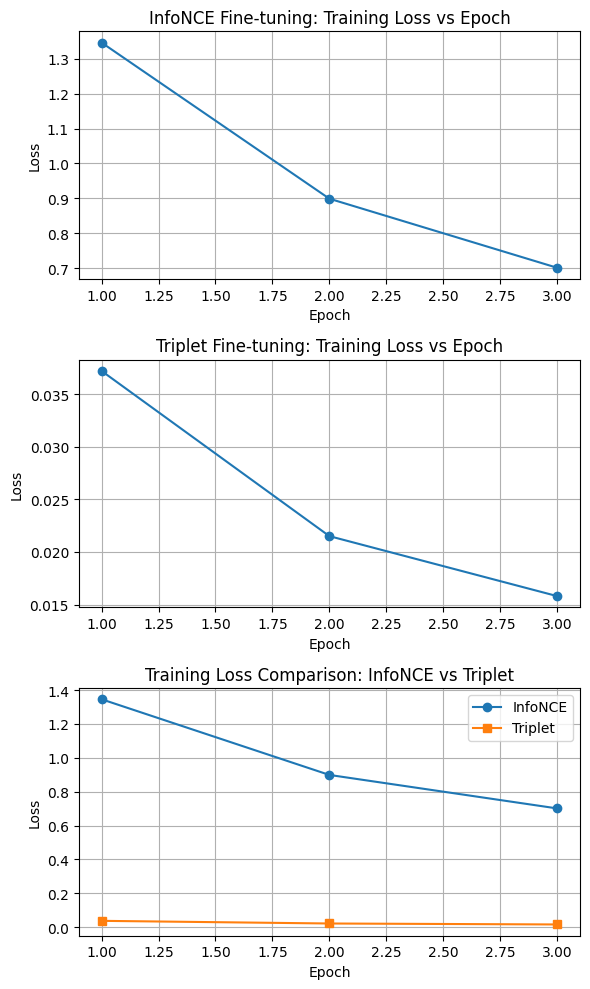

In [1]:
import matplotlib.pyplot as plt

# InfoNCE fine-tuning (20 epochs)
epochs_infonce = [1, 2, 3]
losses_infonce = [1.3460, 0.8990, 0.7012]

# Triplet fine-tuning (3 epochs)
epochs_triplet = [1, 2, 3]
losses_triplet = [0.0372, 0.0215, 0.0158]

# Training loss analysis plots
fig, axes = plt.subplots(3, 1, figsize=(6, 10))

# --- (1) InfoNCE loss curve ---
axes[0].plot(epochs_infonce, losses_infonce, marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("InfoNCE Fine-tuning: Training Loss vs Epoch")
axes[0].grid(True)

# --- (2) Triplet loss curve ---
axes[1].plot(epochs_triplet, losses_triplet, marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Triplet Fine-tuning: Training Loss vs Epoch")
axes[1].grid(True)

# --- (3) Combined comparison plot ---
axes[2].plot(epochs_infonce, losses_infonce, marker="o", label="InfoNCE")
axes[2].plot(epochs_triplet, losses_triplet, marker="s", label="Triplet")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].set_title("Training Loss Comparison: InfoNCE vs Triplet")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### 3. Hyperparameter Experimentation (Learning Rate)

In the baseline setting, we trained the projection layers using a learning rate in the middle range. To understand how sensitive the model is to this choice, we ran the same training procedure again with one rate that was clearly higher and another that was much lower.

We chose 10 epochs because baseline results showed that learning saturates by epoch 10, with both loss and retrieval metrics stabilizing. This keeps training efficient while ensuring fair comparisons.

With the higher learning rate, the loss dropped quickly but the training became unstable. The curve fluctuated instead of moving smoothly, and the retrieval scores reflected this instability. For example, text-to-image Recall@1 improved early on but later slipped from around 0.48 to about 0.47, even though the training loss was the lowest among all runs. This suggests mild overfitting: the model learns fast but does not generalise well.

With the lower learning rate, the model barely progressed. Even after ten epochs, the loss stayed high and the recall metrics were the weakest. The steps were simply too small for the projection layers to adapt, so the model remained close to its zero-shot behaviour.

Comparing the three settings, the baseline learning rate offered the most balanced and consistent results. The higher rate was fast but unstable, and the lower one was too slow to be practical. The baseline remained the most reliable choice for this fine-tuning setup.

(For Plots and more details Please refer to our report)




### 4. Overfitting

There are mild signs of overfitting, but the impact is asymmetric across tasks.   
The training loss keeps falling (1.34 → 0.18), which signals stronger memorisation. 
The validation curves split after epoch 4: image-to-text is volatile, peaking at 0.4605 in epoch 4, dipping to 0.4515 by epoch 8, and only recovering later. Text-to-image stays much more stable and keeps rising from 0.4744 to 0.4907 over the same period. So the overfitting noise mainly hurts I2T temporarily, while T2I keeps benefiting from longer training.

The optimal number of training epochs is 20.   
Epoch 4 looks efficient, but it would cut off both the I2T recovery (up to 0.4677) and the steady T2I gains (0.4744 → 0.4907). The later checkpoint proves the model is still learning useful representations, especially for T2I, so training to epoch 20 is worth the compute.

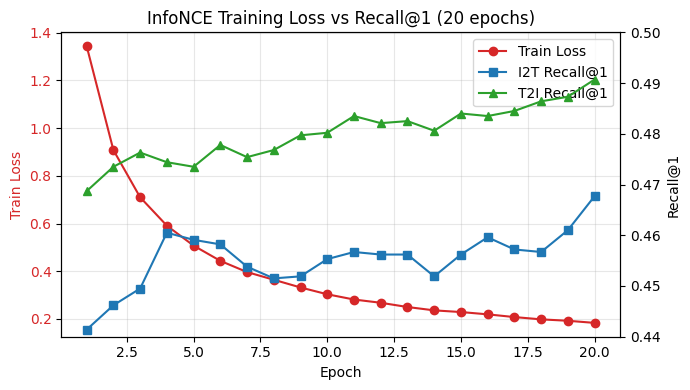

In [1]:
# Plot training loss and validation Recall@1 over 20 epochs (dual y-axis)
import matplotlib.pyplot as plt

epochs = list(range(1, 21))
train_loss = [
    1.3440, 0.9081, 0.7102, 0.5911, 0.5074,
    0.4435, 0.3964, 0.3642, 0.3319, 0.3033,
    0.2813, 0.2677, 0.2499, 0.2358, 0.2288,
    0.2191, 0.2077, 0.1981, 0.1922, 0.1833,
]
recall_i2t_r1 = [
    0.4414, 0.4462, 0.4495, 0.4605, 0.4591,
    0.4582, 0.4538, 0.4515, 0.4519, 0.4553,
    0.4567, 0.4562, 0.4562, 0.4519, 0.4562,
    0.4596, 0.4572, 0.4567, 0.4610, 0.4677,
]
recall_t2i_r1 = [
    0.4687, 0.4735, 0.4763, 0.4744, 0.4735,
    0.4778, 0.4754, 0.4768, 0.4797, 0.4802,
    0.4835, 0.4821, 0.4825, 0.4806, 0.4840,
    0.4835, 0.4845, 0.4864, 0.4873, 0.4907,
]

fig, ax1 = plt.subplots(figsize=(7, 4))
color_loss = "#d62728"
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train Loss", color=color_loss)
line1 = ax1.plot(epochs, train_loss, marker="o", color=color_loss, label="Train Loss")
ax1.tick_params(axis="y", labelcolor=color_loss)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
color_i2t = "#1f77b4"
color_t2i = "#2ca02c"
line2 = ax2.plot(epochs, recall_i2t_r1, marker="s", color=color_i2t, label="I2T Recall@1")
line3 = ax2.plot(epochs, recall_t2i_r1, marker="^", color=color_t2i, label="T2I Recall@1")
ax2.set_ylabel("Recall@1")
ax2.tick_params(axis="y")
ax2.set_ylim(0.44, 0.50)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")
ax1.set_title("InfoNCE Training Loss vs Recall@1 (20 epochs)")
fig.tight_layout()
plt.show()



### 5. Qualitative Analysis:


Best-performing checkpoint: InfoNCE fine-tune with T2I_R@10: 0.841.

**Image→Text Success:** 

image_text_success.jpg

"ground_truth_caption": "A man wearing a black hat is walking through a busy city street ." 

Top-3 captions retrieved:

“A man wearing a black hat is walking through a busy city street.” (GT, cosine 0.435)

“A man and a woman in a silver coat are on a city sidewalk with their backs to the camera.” (0.415)

“Two men in hats stand on a wide sidewalk.” (0.414)

This is a success because the model precisely matched the context (man in hat, urban street) and the distractor captions are semantically close but lack direct agreement with all details.

**Image→Text Failure:** 

image_text_failure.jpg

"ground_truth_caption": "A black and white dog  a black dog and an orange dog are in the grass ". 

Top-3 captions retrieved:

"One dog jumps up to catch a ball as another dog runs towards it ."(GT, cosine 0.419)

"Two black and white dogs run across a green field ."(0.418)

"one brown and white dog chasing a black and white dog through the grass"(GT, cosine 0.412)

The retrieved captions (top-3) mention dogs running or chasing but mis-handle color/count details.This points to two gaps:

 -The model encodes strong coarse semantics (dogs, outdoors, action) but struggles with multi-attribute conjunctions. Because Flickr8k contains many dog-running scenes with similar contexts, the projection heads latch onto dominant cues (species + motion) and ignore secondary ones (exact coloration, number of dogs).

 -The imposed rolled-negative triplet/InfoNCE training doesn’t explicitly encourage attribute disentanglement; positives and negatives often share “dog in park” features, so the embedding may collapse such scenes together. 

**Text→Image Success:** 

Querying text: “A girl in a pink jacket is going headfirst down a red slide,” 

the model retrieves three visually consistent images. 
 
Top‑1 (also the ground truth) “A girl in a pink jacket is going headfirst down a red slide,”
 
Top‑2 shows a child climbing inside a red tube slide (same object, different pose).
 
Top‑3 is another child inside a glowing red slide tunnel. 

All results keep the dominant attributes (child + red slide playground), showing the fine-tuned InfoNCE model can align this caption with multiple semantically similar photos, not just the exact match.
The model succeeds because:

-	The caption combines multiple distinctive cues that co-occur reliably—“girl”, “pink jacket”, “red slide”. In the dataset there are only a handful of playground shots with that color palette, so during InfoNCE training those examples become well separated from other captions. 

-	The negatives are diverse (parks, beaches, animals), forcing the projection heads to attend to the specific conjunction of “child + pink outerwear + bright red slide/tunnel”.



**Text→Image Failure:**  

Querying text: “A black and white dog, a black dog and an orange dog are in the grass.” 
 
Ground-truth image
Ground-truth shows three differently colored dogs running in a park, but the retrieved top 3 images were:
 
Top‑1 two black dogs tugging a toy with a tan dog near a house.
 
Top‑2 three dogs (white/brown/black) running but with different composition and lighting.

 
Top‑3 two dogs (white/black and brown) running, missing the third dog and orange coloring.
Likely failure causes: 
The cues are less distinctive and more combinatorial. Flickr8k contains many “dogs running on grass” images that share the dominant features (species, outdoors, motion). The projection heads mostly learn to recognize that coarse concept. Color/count attributes (“black and white”, “orange”, “three dogs”) are harder to train.

(codes for this experiment is in the next cell for your reference)

In [ ]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class FlickrDataset(Dataset):
    """Small wrapper so that we can pick arbitrary indices while sharing the cached dataset."""

    def __init__(self, hf_dataset, indices: Iterable[int], processor: CLIPProcessor):
        self.hf_dataset = hf_dataset
        self.indices = list(indices)
        self.processor = processor

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        ex = self.hf_dataset[self.indices[idx]]
        out = self.processor(
            images=ex["image"],
            text=ex["text"],
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {k: v.squeeze(0) for k, v in out.items()}


def setup_peft(model: CLIPModel) -> CLIPModel:
    """Freeze encoders and leave only the projection heads trainable."""
    for p in model.text_model.parameters():
        p.requires_grad = False
    for p in model.vision_model.parameters():
        p.requires_grad = False
    for p in model.text_projection.parameters():
        p.requires_grad = True
    for p in model.visual_projection.parameters():
        p.requires_grad = True
    if hasattr(model, "logit_scale"):
        model.logit_scale.requires_grad = False
    return model


def info_nce_loss(image_features: torch.Tensor, text_features: torch.Tensor, temperature: float = 0.07) -> torch.Tensor:
    image_features = F.normalize(image_features, dim=1)
    text_features = F.normalize(text_features, dim=1)
    logits = image_features @ text_features.T / temperature
    labels = torch.arange(image_features.size(0), device=logits.device)
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2


@torch.no_grad()
def calculate_recall_at_k(
    model: CLIPModel, processor: CLIPProcessor, test_dataset: FlickrDataset, device: torch.device, k_values=(1, 5, 10)
) -> Dict[str, float]:
    model.eval()
    I2C = defaultdict(list)
    unique_images = {}
    for idx in test_dataset.indices:
        ex = test_dataset.hf_dataset[idx]
        I2C[idx].append(ex["text"])
        unique_images.setdefault(idx, ex["image"])
    image_embeds = []
    for image in unique_images.values():
        inputs = processor(images=image, return_tensors="pt").to(device)
        image_embeds.append(model.get_image_features(**inputs))
    image_embeds = F.normalize(torch.cat(image_embeds), dim=-1)
    texts = [caption for idx in unique_images for caption in I2C[idx]]
    text_embeds = []
    for start in range(0, len(texts), 64):
        chunk = texts[start : start + 64]
        inputs = processor(text=chunk, padding=True, truncation=True, return_tensors="pt").to(device)
        text_embeds.append(model.get_text_features(**inputs))
    text_embeds = F.normalize(torch.cat(text_embeds), dim=-1)
    sim = image_embeds @ text_embeds.T
    metrics = {}
    image_order = list(unique_images.keys())
    idx_to_texts = [[] for _ in image_order]
    text_owner = []
    running_text_idx = 0
    for img_pos, img_idx in enumerate(image_order):
        captions = I2C[img_idx]
        for _ in captions:
            idx_to_texts[img_pos].append(running_text_idx)
            text_owner.append(img_pos)
            running_text_idx += 1
    for k in k_values:
        topk = torch.topk(sim, k, dim=1).indices
        correct = sum(bool(set(topk[i].tolist()) & set(idx_to_texts[i])) for i in range(len(image_order)))
        metrics[f"I2T_R@{k}"] = correct / len(image_order)
    sim_t = sim.T
    for k in k_values:
        topk = torch.topk(sim_t, k, dim=1).indices
        correct = sum(text_owner[i] in topk[i].tolist() for i in range(len(text_owner)))
        metrics[f"T2I_R@{k}"] = correct / len(text_owner)
    return metrics


class RetrievalTrainer:
    def __init__(self, model: CLIPModel, processor: CLIPProcessor, loader: DataLoader, test_dataset: FlickrDataset, device: torch.device):
        self.model = model
        self.processor = processor
        self.loader = loader
        self.test_dataset = test_dataset
        self.device = device

    def train(self, epochs: int, lr: float):
        optim = torch.optim.AdamW(filter(lambda p: p.requires_grad, self.model.parameters()), lr=lr)
        best_metrics = None
        for epoch in range(epochs):
            self.model.train()
            total = 0.0
            for batch in self.loader:
                pixel_values = batch["pixel_values"].to(self.device)
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                image_features = self.model.get_image_features(pixel_values=pixel_values)
                text_features = self.model.get_text_features(input_ids=input_ids, attention_mask=attention_mask)
                loss = info_nce_loss(image_features, text_features)
                optim.zero_grad()
                loss.backward()
                optim.step()
                total += loss.item() * pixel_values.size(0)
            avg_loss = total / len(self.loader.dataset)
            metrics = calculate_recall_at_k(self.model, self.processor, self.test_dataset, self.device)
            best_metrics = metrics
            print(f"Epoch {epoch + 1} | Loss {avg_loss:.4f} | Metrics {metrics}")
        return best_metrics


def embed_images(model: CLIPModel, processor: CLIPProcessor, image_list: List, batch_size: int, device: torch.device) -> torch.Tensor:
    feats = []
    for start in range(0, len(image_list), batch_size):
        batch = image_list[start : start + batch_size]
        inputs = processor(images=batch, return_tensors="pt").to(device)
        feats.append(F.normalize(model.get_image_features(**inputs), dim=-1).cpu())
    return torch.cat(feats)


def embed_texts(model: CLIPModel, processor: CLIPProcessor, text_list: List[str], batch_size: int, device: torch.device) -> torch.Tensor:
    feats = []
    for start in range(0, len(text_list), batch_size):
        batch = text_list[start : start + batch_size]
        inputs = processor(text=batch, padding=True, truncation=True, return_tensors="pt").to(device)
        feats.append(F.normalize(model.get_text_features(**inputs), dim=-1).cpu())
    return torch.cat(feats)


def export_qualitative(
    model: CLIPModel,
    processor: CLIPProcessor,
    test_dataset: FlickrDataset,
    device: torch.device,
    metrics: Dict[str, float],
    k: int = 3,
    output_dir: Path = Path("qualitative_outputs"),
    manual_image_success: Optional[int] = None,
    manual_image_failure: Optional[int] = None,
    manual_text_success: Optional[int] = None,
    manual_text_failure: Optional[int] = None,
) -> Dict:
    test_images = [test_dataset.hf_dataset[i]["image"] for i in test_dataset.indices]
    test_texts = [test_dataset.hf_dataset[i]["text"] for i in test_dataset.indices]
    image_embeds = embed_images(model, processor, test_images, batch_size=32, device=device)
    text_embeds = embed_texts(model, processor, test_texts, batch_size=64, device=device)
    sim = image_embeds @ text_embeds.T
    image_topk = torch.topk(sim, k, dim=1)
    text_topk = torch.topk(sim.T, k, dim=1)

    def find_success_failure(topk_indices, mode: str):
        success = None
        failure = None
        for idx in range(len(topk_indices)):
            hits = topk_indices[idx].tolist()
            if mode == "image" and idx in hits:
                success = idx
                break
            if mode == "text" and idx in hits:
                success = idx
                break
        for idx in range(len(topk_indices)):
            hits = topk_indices[idx].tolist()
            if mode == "image" and idx not in hits:
                failure = idx
                break
            if mode == "text" and idx not in hits:
                failure = idx
                break
        if success is None:
            success = 0
        if failure is None:
            failure = 0
        return success, failure

    img_success, img_failure = find_success_failure(image_topk.indices, "image")
    txt_success, txt_failure = find_success_failure(text_topk.indices, "text")
    if manual_image_success is not None:
        img_success = manual_image_success
    if manual_image_failure is not None:
        img_failure = manual_image_failure
    if manual_text_success is not None:
        txt_success = manual_text_success
    if manual_text_failure is not None:
        txt_failure = manual_text_failure

    output_dir.mkdir(exist_ok=True)

    def save_image(image, path: Path):
        image.save(path)
        return str(path)

    result = {"metrics": metrics}

    def build_caption_list(image_idx: int):
        return [
            {
                "rank": rank,
                "text_index": txt_idx,
                "caption": test_texts[txt_idx],
                "similarity": float(sim[image_idx, txt_idx]),
                "is_correct": txt_idx == image_idx,
            }
            for rank, txt_idx in enumerate(image_topk.indices[image_idx].tolist(), start=1)
        ]

    image_success_path = save_image(test_images[img_success], output_dir / "image_query_success.jpg")
    image_failure_path = save_image(test_images[img_failure], output_dir / "image_query_failure.jpg")
    result["image_to_text_success"] = {
        "index": img_success,
        "image_path": image_success_path,
        "ground_truth_caption": test_texts[img_success],
        "top_captions": build_caption_list(img_success),
    }
    result["image_to_text_failure"] = {
        "index": img_failure,
        "image_path": image_failure_path,
        "ground_truth_caption": test_texts[img_failure],
        "top_captions": build_caption_list(img_failure),
    }

    def build_image_list(text_idx: int, prefix: str):
        paths = []
        imgs = []
        for rank, img_idx in enumerate(text_topk.indices[text_idx].tolist(), start=1):
            path = output_dir / f"{prefix}_top{rank}.jpg"
            imgs.append(
                {
                    "rank": rank,
                    "image_index": img_idx,
                    "image_path": save_image(test_images[img_idx], path),
                    "similarity": float(sim[img_idx, text_idx]),
                    "is_correct": img_idx == text_idx,
                }
            )
            paths.append(path)
        return imgs

    text_success_gt_path = save_image(test_images[txt_success], output_dir / "text_query_success_gt.jpg")
    text_failure_gt_path = save_image(test_images[txt_failure], output_dir / "text_query_failure_gt.jpg")
    result["text_to_image_success"] = {
        "index": txt_success,
        "text": test_texts[txt_success],
        "ground_truth_image_path": text_success_gt_path,
        "retrieved_images": build_image_list(txt_success, "text_query_success"),
    }
    result["text_to_image_failure"] = {
        "index": txt_failure,
        "text": test_texts[txt_failure],
        "ground_truth_image_path": text_failure_gt_path,
        "retrieved_images": build_image_list(txt_failure, "text_query_failure"),
    }

    with open(output_dir / "qualitative_result.json", "w") as f:
        json.dump(result, f, indent=2)
    return result


def main():
    global processor  # allow helper functions to access the processor without threading it everywhere
    set_seed(42)
    device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
    model_name = "openai/clip-vit-base-patch32"
    model = CLIPModel.from_pretrained(model_name).to(device)
    processor = CLIPProcessor.from_pretrained(model_name)
    model = setup_peft(model)

    flickr = load_dataset("Naveengo/flickr8k")["train"]
    indices = list(range(len(flickr)))
    random.shuffle(indices)
    train_indices = indices[:6000]
    test_indices = indices[6000:]
    train_dataset = FlickrDataset(flickr, train_indices, processor)
    test_dataset = FlickrDataset(flickr, test_indices, processor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    trainer = RetrievalTrainer(model, processor, train_loader, test_dataset, device)
    metrics = trainer.train(epochs=3, lr=1e-5)
    # Force a text->image success example whose top-3 matches stay semantically consistent.
    manual_text_success_idx = 4  # "A girl in a pink jacket is going headfirst down a red slide ."
    export_qualitative(
        model,
        processor,
        test_dataset,
        device,
        metrics,
        k=3,
        manual_text_success=manual_text_success_idx,
    )


if __name__ == "__main__":
    main()




### 6. Discussion Question (Bonus)

We investigated whether training only one projection layer (visual or text) could match the performance of training both. Three strategies were tested: Visual-Only (train visual projection only), Text-Only (train text projection only), and Both Projections (baseline). All used learning rate 1e-5 for 10 epochs on Flickr8k.
 
Visual-Only achieves the best Text-to-Image (T2I) performance: T2I R@1 of 0.5055 (5.2% better than Both), T2I R@5 of 0.7838 (2.4% better), and T2I R@10 of 0.8656 (2.0% better). Conversely, Text-Only excels at Image-to-Text (I2T) retrieval with I2T R@5 of 0.7470 and I2T R@10 of 0.8436, matching the Both baseline. However, Text-Only severely degrades T2I performance below the zero-shot baseline.
 
From these outcomes, we infer that the visual side adapts more effectively on Flickr8k. The images show more variation from CLIP’s original training distribution than the captions, so adjusting the visual projection seems to help more. In contrast, the text captions are short and descriptive, and CLIP already handles that style well. This may explain why updating only the text projection offers limited gains and can negatively affect tasks involving image retrieval.
Another interesting finding is that visual-only training outperforms training both projections. We infer two possible reasons:

1. Regularisation effect

Training only one projection layer reduces the chance of overfitting. The model that trained both projections reached the lowest training loss, but the retrieval performance did not reflect that. It likely fit the training set too closely without improving generalisation.

2. Uneven domain shift

Flickr8k images differ more from CLIP’s pre-training images than its captions differ from CLIP’s pre-training text. The text side might already be “good enough,” while the visual side needs more adjustment. Updating both at once may cause the two projections to move in directions that don’t complement each other perfectly.

Overall, the results show a clear asymmetry. For text-to-image retrieval, updating the visual projection is the most beneficial. For image-to-text retrieval, updating the text projection helps somewhat, but the improvement is not as pronounced.

In short, we infer that the visual projection is the main bottleneck for this dataset, and focusing on it gives the best balance between performance and efficiency.

(For Plots and more details Please refer to our report)
